# Семинар 6: Масштабирование рекомендательных систем 

## Построение Datamart 

В этом семинаре мы реализуем datamart подход к организации данных для рекомендательных систем:


### Расширенные фичи:
- User-item фичи (базовые)
- User-category фичи
- User-author (directors) фичи
- User-release_year фичи
- User-cluster фичи (кластеризация по age/income/sex)
- User-cluster-item фичи
- User-cluster-gender фичи

Используем датасет МТС из соревнования: https://ods.ai/competitions/competition-recsys-21/data

In [1]:
import pandas as pd
import numpy as np
import polars as pl
from pathlib import Path
from tqdm import tqdm
from typing import Dict, List, Any
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

%matplotlib inline

## 1. Загрузка всех данных МТС

In [2]:
# Загружаем interactions
df_interactions = pd.read_csv("../../interactions.csv")
print(f"Interactions: {df_interactions.shape}")
df_interactions.head()

Interactions: (5476251, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [3]:
# Загружаем items
df_items = pd.read_csv("../items.csv")
print(f"Items: {df_items.shape}")
print(f"\nКолонки: {df_items.columns.tolist()}")
df_items.head()

Items: (15963, 14)

Колонки: ['item_id', 'content_type', 'title', 'title_orig', 'release_year', 'genres', 'countries', 'for_kids', 'age_rating', 'studios', 'directors', 'actors', 'description', 'keywords']


,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [4]:
# Загружаем users
df_users = pd.read_csv("../users.csv")
print(f"Users: {df_users.shape}")
print(f"\nКолонки: {df_users.columns.tolist()}")
df_users.head()

Users: (840197, 5)

Колонки: ['user_id', 'age', 'income', 'sex', 'kids_flg']


,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


## 2. Подготовка данных

In [5]:
# Обрабатываем дату
df_interactions["last_watch_dt"] = pd.to_datetime(df_interactions["last_watch_dt"]) - pd.to_datetime(df_interactions["last_watch_dt"]).min()
df_interactions["day"] = df_interactions.last_watch_dt.apply(lambda x: int(str(x).split()[0]))

print(f"Диапазон дней: {df_interactions['day'].min()} - {df_interactions['day'].max()}")

Диапазон дней: 0 - 162


In [6]:
# Разбиваем на train/test
max_watch_dt = df_interactions['day'].max()
train_df_pd = df_interactions.loc[df_interactions.day < max_watch_dt - 30].copy()
test_df_pd = df_interactions.loc[df_interactions.day >= max_watch_dt - 30].copy()

# Фильтруем
test_df_pd = test_df_pd.loc[test_df_pd.user_id.isin(train_df_pd.user_id.unique())].copy()
test_df_pd = test_df_pd.loc[test_df_pd.item_id.isin(train_df_pd.item_id.unique())].copy()

# Сэмплируем 50000 пользователей
np.random.seed(42)
train_users = train_df_pd['user_id'].unique()
test_users = test_df_pd.user_id.unique()
n_users = 50_000

intersection = np.intersect1d(train_users, test_users)
sampled_users = np.random.choice(intersection, n_users, replace=False)

train_df_pd = train_df_pd[train_df_pd['user_id'].isin(sampled_users)]
test_df_pd = test_df_pd[test_df_pd['user_id'].isin(sampled_users)]

print(f"Train: {train_df_pd.shape}, Test: {test_df_pd.shape}")

Train: (481529, 6), Test: (228357, 6)


## 3. Обогащение данными из items и users

In [7]:
# Извлекаем первый жанр и первого режиссера для упрощения
df_items['first_genre'] = df_items['genres'].fillna('unknown').apply(lambda x: x.split(',')[0].strip() if pd.notna(x) and x != '' else 'unknown')
df_items['first_director'] = df_items['directors'].fillna('unknown').apply(lambda x: x.split(',')[0].strip() if pd.notna(x) and x != '' else 'unknown')
df_items['release_year'] = df_items['release_year'].fillna(0).astype(int)

# Выбираем нужные колонки
items_subset = df_items[['item_id', 'content_type', 'first_genre', 'first_director', 'release_year', 'for_kids']].copy()
items_subset.head()

,item_id,content_type,first_genre,first_director,release_year,for_kids
0,10711,film,драмы,Педро Альмодовар,2002,NaN
1,2508,film,зарубежные,Скот Армстронг,2014,NaN
2,10716,film,криминал,Адам П. Калтраро,2011,NaN
3,7868,film,драмы,Эндрю Хэй,2015,NaN
4,16268,film,драмы,Виктор Садовский,1978,NaN


In [8]:
# Кластеризация пользователей
df_users_clean = df_users.copy()

# Заполняем пропуски
df_users_clean['age'] = df_users_clean['age'].fillna('unknown')
df_users_clean['income'] = df_users_clean['income'].fillna('unknown')
df_users_clean['sex'] = df_users_clean['sex'].fillna('unknown')
df_users_clean['kids_flg'] = df_users_clean['kids_flg'].fillna(0)

# Энкодим категориальные переменные
le_age = LabelEncoder()
le_income = LabelEncoder()
le_sex = LabelEncoder()

df_users_clean['age_encoded'] = le_age.fit_transform(df_users_clean['age'])
df_users_clean['income_encoded'] = le_income.fit_transform(df_users_clean['income'])
df_users_clean['sex_encoded'] = le_sex.fit_transform(df_users_clean['sex'])

# K-means кластеризация
kmeans_features = df_users_clean[['age_encoded', 'income_encoded', 'sex_encoded', 'kids_flg']].values
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_users_clean['user_cluster'] = kmeans.fit_predict(kmeans_features)

users_subset = df_users_clean[['user_id', 'age', 'income', 'sex', 'kids_flg', 'user_cluster']].copy()
print(f"Пользователей с кластерами: {users_subset.shape}")
print(f"Распределение по кластерам:\n{users_subset['user_cluster'].value_counts().sort_index()}")
users_subset.head()

Пользователей с кластерами: (840197, 6)
Распределение по кластерам:
user_cluster
0     92589
1    133285
2     92875
3     94624
4     93325
5    122134
6     99471
7     14173
8     17402
9     80319
Name: count, dtype: int64


,user_id,age,income,sex,kids_flg,user_cluster
0,973171,age_25_34,income_60_90,М,1,5
1,962099,age_18_24,income_20_40,М,0,2
2,1047345,age_45_54,income_40_60,Ж,0,3
3,721985,age_45_54,income_20_40,Ж,0,0
4,704055,age_35_44,income_60_90,Ж,0,3


In [9]:
# Джойним все данные
train_enriched = train_df_pd.merge(items_subset, on='item_id', how='left')
train_enriched = train_enriched.merge(users_subset, on='user_id', how='left')

# Заполняем пропуски
train_enriched['first_genre'] = train_enriched['first_genre'].fillna('unknown')
train_enriched['first_director'] = train_enriched['first_director'].fillna('unknown')
train_enriched['release_year'] = train_enriched['release_year'].fillna(0).astype(int)
train_enriched['user_cluster'] = train_enriched['user_cluster'].fillna(-1).astype(int)
train_enriched['sex'] = train_enriched['sex'].fillna('unknown')

print(f"Train enriched: {train_enriched.shape}")
print(f"Колонки: {train_enriched.columns.tolist()}")
train_enriched.head()

Train enriched: (481529, 16)
Колонки: ['user_id', 'item_id', 'last_watch_dt', 'total_dur', 'watched_pct', 'day', 'content_type', 'first_genre', 'first_director', 'release_year', 'for_kids', 'age', 'income', 'sex', 'kids_flg', 'user_cluster']


,user_id,item_id,last_watch_dt,total_dur,watched_pct,day,content_type,first_genre,first_director,release_year,for_kids,age,income,sex,kids_flg,user_cluster
0,176549,9506,59 days,4250,72.0,59,film,фэнтези,Крис Бак,2013,NaN,age_35_44,income_40_60,М,0.0,3
1,163922,1931,45 days,155,0.0,45,series,драмы,Крэйг Зобел,2021,NaN,age_25_34,income_20_40,М,0.0,6
2,35423,5648,89 days,52,1.0,89,film,драмы,София Коппола,2003,NaN,age_25_34,income_60_90,Ж,0.0,5
3,261118,4495,127 days,5786,100.0,127,film,драмы,Иван Болотников,2020,NaN,NaN,NaN,unknown,NaN,-1
4,94135,1819,20 days,802,12.0,20,film,комедии,Виктор Шамиров,2020,NaN,age_45_54,income_20_40,М,0.0,0


In [10]:
# Конвертируем в Polars для эффективной работы
df = pl.from_pandas(train_enriched[[
    'user_id', 'item_id', 'day', 'watched_pct',
    'first_genre', 'first_director', 'release_year', 
    'user_cluster', 'sex'
]])

print(f"Размер датасета: {df.shape}")
print(f"Диапазон дней: {df['day'].min()} - {df['day'].max()}")
df.head()

Размер датасета: (481529, 9)
Диапазон дней: 0 - 131


user_id,item_id,day,watched_pct,first_genre,first_director,release_year,user_cluster,sex
i64,i64,i64,f64,str,str,i64,i64,str
176549,9506,59,72.0,"""фэнтези""","""Крис Бак""",2013,3,"""М"""
163922,1931,45,0.0,"""драмы""","""Крэйг Зобел""",2021,6,"""М"""
35423,5648,89,1.0,"""драмы""","""София Коппола""",2003,5,"""Ж"""
261118,4495,127,100.0,"""драмы""","""Иван Болотников""",2020,-1,"""unknown"""
94135,1819,20,12.0,"""комедии""","""Виктор Шамиров""",2020,0,"""М"""


## 4. Подход №1: Datamart с расчетом на каждую дату

### 4.1 Raw слой - сохраняем данные по дням

In [11]:
# Создаем структуру директорий для datamart
datamart_path = Path('datamart_mts_extended')
raw_path = datamart_path / 'raw'
agg_path = datamart_path / 'agg'
feat_path = datamart_path / 'feat'

for path in [raw_path, agg_path, feat_path]:
    path.mkdir(parents=True, exist_ok=True)

print("Структура директорий создана")

Структура директорий создана


In [12]:
# Сохраняем raw слой для каждого дня (только первые 30 дней для примера)
def save_raw_layer(df: pl.DataFrame, output_dir: Path, max_day: int = 30):
    """
    Сохраняет raw данные для каждого дня
    """
    df_filtered = df.filter(pl.col('day') <= max_day)
    
    for day in tqdm(range(df_filtered['day'].min(), max_day + 1), desc="Saving raw layers"):
        day_df = df_filtered.filter(pl.col('day') == day)
        
        if len(day_df) > 0:
            day_file = output_dir / f"day_{str(day).zfill(5)}.parquet"
            day_df.write_parquet(day_file)
    
    print(f"Raw layer сохранен в {output_dir}")

save_raw_layer(df, raw_path, max_day=30)

Saving raw layers: 100%|██████████| 31/31 [00:00<00:00, 158.74it/s]

Raw layer сохранен в datamart_mts_extended/raw


### 4.2 Agg слой - агрегируем на каждую дату

In [13]:
def build_agg_layer(df: pl.DataFrame, day: int) -> Dict[str, pl.DataFrame]:
    """
    Строит агрегированные таблицы на дату day
    (используя данные ДО этой даты, не включая сам day)
    """
    df_before = df.filter(pl.col('day') == day)
    
    if len(df_before) == 0:
        return {}
    
    agg_dict = {}
    
    # 1. User-item агрегаты
    user_item_agg = df_before.group_by(['user_id', 'item_id']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct'),
        pl.col('watched_pct').max().alias('max_watched_pct')
    ])
    agg_dict['user_item'] = user_item_agg
    
    # 2. User-genre агрегаты
    user_genre_agg = df_before.group_by(['user_id', 'first_genre']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['user_genre'] = user_genre_agg
    
    # 3. User-director агрегаты
    user_director_agg = df_before.group_by(['user_id', 'first_director']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['user_director'] = user_director_agg
    
    # 4. User-release_year агрегаты
    user_year_agg = df_before.filter(pl.col('release_year') > 0).group_by(['user_id', 'release_year']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['user_release_year'] = user_year_agg
    
    # 5. User-cluster-item агрегаты
    cluster_item_agg = df_before.filter(pl.col('user_cluster') >= 0).group_by(['user_cluster', 'item_id']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['cluster_item'] = cluster_item_agg
    
    # 6. User-cluster-genre агрегаты
    cluster_genre_agg = df_before.filter(pl.col('user_cluster') >= 0).group_by(['user_cluster', 'first_genre']).agg([
        pl.count().alias('num_interactions'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['cluster_genre'] = cluster_genre_agg
    
    # 7. User агрегаты
    user_agg = df_before.group_by(['user_id']).agg([
        pl.count().alias('total_interactions'),
        pl.col('item_id').n_unique().alias('num_unique_items'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['user'] = user_agg
    
    # 8. Item агрегаты
    item_agg = df_before.group_by(['item_id']).agg([
        pl.count().alias('total_views'),
        pl.col('user_id').n_unique().alias('num_unique_users'),
        pl.col('watched_pct').mean().alias('avg_watched_pct')
    ])
    agg_dict['item'] = item_agg
    
    return agg_dict

In [14]:
# Сохраняем agg слой для каждого дня
def save_agg_layer_for_all_days(df: pl.DataFrame, output_dir: Path, max_day: int = 30):
    """
    Сохраняет agg слой для каждого дня
    """
    df_filtered = df.filter(pl.col('day') <= max_day)
    
    for day in tqdm(range(df_filtered['day'].min() + 1, max_day + 1), desc="Building agg layers"):
        agg_data = build_agg_layer(df_filtered, day)
        
        if not agg_data:
            continue
        
        # Сохраняем каждый тип агрегатов
        for agg_type, agg_df in agg_data.items():
            agg_type_dir = output_dir / agg_type
            agg_type_dir.mkdir(parents=True, exist_ok=True)
            
            agg_file = agg_type_dir / f"day_{str(day).zfill(5)}.parquet"
            agg_df.write_parquet(agg_file)
    
    print(f"Agg layer сохранен в {output_dir}")

save_agg_layer_for_all_days(df, agg_path, max_day=30)

Building agg layers:   0%|          | 0/30 [00:00<?, ?it/s]/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/628009990.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('num_interactions'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/628009990.py:23: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('num_interactions'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/628009990.py:30: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('num_interactions'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/628009990.py:37: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias('num_interactions'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/628009990.py:44: DeprecationWarning: `pl.count()` is deprecated. Please 

Agg layer сохранен в datamart_mts_extended/agg


### 4.3 Feat слой - строим признаки на каждую дату

In [15]:
def build_feat_layer(df: pl.DataFrame, day: int, windows: List[int] = [7, 14]) -> Dict[str, pl.DataFrame]:
    """
    Строит признаки на дату day для каждого типа среза отдельно
    Фичи считаются БЕЗ ДАННЫХ ЗА ЭТУ ДАТУ!
    Возвращает словарь {slice_name: features_df}
    Названия колонок включают префикс типа среза для уникальности
    """
    feat_dict = {}
    
    for window in windows:
        df_window = df.filter(
            (pl.col('day') < day) & (pl.col('day') >= day - window)
        )
        
        if len(df_window) == 0:
            continue
        
        # 1. User-item фичи
        user_item_feats = df_window.group_by(['user_id', 'item_id']).agg([
            pl.count().alias(f'ui_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'ui_avg_watched_{window}d'),
            pl.col('watched_pct').max().alias(f'ui_max_watched_{window}d')
        ])
        
        if 'user_item' not in feat_dict:
            feat_dict['user_item'] = user_item_feats
        else:
            feat_dict['user_item'] = feat_dict['user_item'].join(
                user_item_feats, on=['user_id', 'item_id'], how='outer'
            )
        
        # 2. User-genre фичи
        user_genre_feats = df_window.group_by(['user_id', 'first_genre']).agg([
            pl.count().alias(f'ug_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'ug_avg_watched_{window}d')
        ])
        
        if 'user_genre' not in feat_dict:
            feat_dict['user_genre'] = user_genre_feats
        else:
            feat_dict['user_genre'] = feat_dict['user_genre'].join(
                user_genre_feats, on=['user_id', 'first_genre'], how='outer'
            )
        
        # 3. User-director фичи
        user_director_feats = df_window.group_by(['user_id', 'first_director']).agg([
            pl.count().alias(f'ud_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'ud_avg_watched_{window}d')
        ])
        
        if 'user_director' not in feat_dict:
            feat_dict['user_director'] = user_director_feats
        else:
            feat_dict['user_director'] = feat_dict['user_director'].join(
                user_director_feats, on=['user_id', 'first_director'], how='outer'
            )
        
        # 4. User-release_year фичи
        user_year_feats = df_window.filter(pl.col('release_year') > 0).group_by(['user_id', 'release_year']).agg([
            pl.count().alias(f'uy_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'uy_avg_watched_{window}d')
        ])
        
        if len(user_year_feats) > 0:
            if 'user_release_year' not in feat_dict:
                feat_dict['user_release_year'] = user_year_feats
            else:
                feat_dict['user_release_year'] = feat_dict['user_release_year'].join(
                    user_year_feats, on=['user_id', 'release_year'], how='outer'
                )
        
        # 5. Cluster-item фичи
        cluster_item_feats = df_window.filter(pl.col('user_cluster') >= 0).group_by(['user_cluster', 'item_id']).agg([
            pl.count().alias(f'ci_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'ci_avg_watched_{window}d')
        ])
        
        if len(cluster_item_feats) > 0:
            if 'cluster_item' not in feat_dict:
                feat_dict['cluster_item'] = cluster_item_feats
            else:
                feat_dict['cluster_item'] = feat_dict['cluster_item'].join(
                    cluster_item_feats, on=['user_cluster', 'item_id'], how='outer'
                )
        
        # 6. Cluster-genre фичи
        cluster_genre_feats = df_window.filter(pl.col('user_cluster') >= 0).group_by(['user_cluster', 'first_genre']).agg([
            pl.count().alias(f'cg_num_views_{window}d'),
            pl.col('watched_pct').mean().alias(f'cg_avg_watched_{window}d')
        ])
        
        if len(cluster_genre_feats) > 0:
            if 'cluster_genre' not in feat_dict:
                feat_dict['cluster_genre'] = cluster_genre_feats
            else:
                feat_dict['cluster_genre'] = feat_dict['cluster_genre'].join(
                    cluster_genre_feats, on=['user_cluster', 'first_genre'], how='outer'
                )
        
        # 7. User фичи (агрегированные статистики пользователя)
        user_feats = df_window.group_by(['user_id']).agg([
            pl.count().alias(f'u_total_interactions_{window}d'),
            pl.col('item_id').n_unique().alias(f'u_num_unique_items_{window}d'),
            pl.col('watched_pct').mean().alias(f'u_avg_watched_{window}d')
        ])
        
        if 'user' not in feat_dict:
            feat_dict['user'] = user_feats
        else:
            feat_dict['user'] = feat_dict['user'].join(
                user_feats, on=['user_id'], how='outer'
            )
        
        # 8. Item фичи (агрегированные статистики айтема)
        item_feats = df_window.group_by(['item_id']).agg([
            pl.count().alias(f'i_total_views_{window}d'),
            pl.col('user_id').n_unique().alias(f'i_num_unique_users_{window}d'),
            pl.col('watched_pct').mean().alias(f'i_avg_watched_{window}d')
        ])
        
        if 'item' not in feat_dict:
            feat_dict['item'] = item_feats
        else:
            feat_dict['item'] = feat_dict['item'].join(
                item_feats, on=['item_id'], how='outer'
            )
    
    # Заполняем null значения нулями
    for feat_type in feat_dict:
        feat_dict[feat_type] = feat_dict[feat_type].fill_null(0)
    
    return feat_dict

In [16]:
# Сохраняем feat слой для каждого дня (отдельно по типам)
def save_feat_layer_for_all_days(
    df: pl.DataFrame, 
    output_dir: Path, 
    max_day: int = 30,
    windows: List[int] = [7, 14]
):
    """
    Сохраняет feat слой для каждого дня, разбивая по типам срезов
    Структура: feat/{feat_type}/day_XXXXX.parquet
    """
    df_filtered = df.filter(pl.col('day') <= max_day)
    
    for day in tqdm(range(df_filtered['day'].min() + 1, max_day + 1), desc="Building feat layers"):
        feat_data = build_feat_layer(df_filtered, day, windows=windows)
        
        if not feat_data:
            continue
        
        # Сохраняем каждый тип фичей отдельно
        for feat_type, feat_df in feat_data.items():
            feat_type_dir = output_dir / feat_type
            feat_type_dir.mkdir(parents=True, exist_ok=True)
            
            feat_file = feat_type_dir / f"day_{str(day).zfill(5)}.parquet"
            feat_df.write_parquet(feat_file)
    
    print(f"Feat layer сохранен в {output_dir}")

save_feat_layer_for_all_days(df, feat_path, max_day=30, windows=[7, 14])

Building feat layers:   0%|          | 0/30 [00:00<?, ?it/s]/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/3493204612.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias(f'ui_num_views_{window}d'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/3493204612.py:34: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias(f'ug_num_views_{window}d'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/3493204612.py:47: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias(f'ud_num_views_{window}d'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/3493204612.py:60: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias(f'uy_num_views_{window}d'),
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/3493204612.py:74: DeprecationWarning: `

Feat layer сохранен в datamart_mts_extended/feat


### 4.4 Basis и Dataset

In [18]:
import polars as pl


def build_basis(df: pl.DataFrame, day: int, n_negatives: int = 50) -> pl.DataFrame:
    """
    Строит basis на указанный день.

    Позитивы:
        все user-item взаимодействия в этот день → label = 1

    Негативы:
        для каждой session_id семплируется n_negatives случайных item_id
        из глобального пула айтемов (исключая уже просмотренные в этот день)
        → label = 0
    """

    # --- 1. Позитивные примеры ---
    positives = (
        df
        .filter(pl.col("day") == day)
        .with_columns([
            (pl.col("day").cast(pl.Utf8) + "_" + pl.col("user_id").cast(pl.Utf8))
            .alias("session_id"),
            pl.lit(1).alias("label")
        ])
        .select(["session_id", "day", "user_id", "item_id", "label"])
    )

    if positives.height == 0:
        return positives

    # --- 2. Глобальный пул айтемов ---
    all_items = df.select("item_id").unique()

    # --- 3. Айтемы, уже просмотренные пользователями в этот день ---
    user_items = positives.select(["session_id", "user_id", "item_id"])

    # --- 4. Формируем негативный пул через cross join ---
    sessions = positives.select(["session_id", "user_id", "day"]).unique()

    negatives = (
        sessions
        .join(all_items, how="cross")
        .join(
            user_items,
            on=["session_id", "user_id", "item_id"],
            how="anti",   # исключаем уже существующие позитивы
        )
    )

    # --- 5. Семплируем n_negatives на каждую session_id ---
    negatives = (
        negatives
        .with_columns(pl.int_range(0, pl.count()).over("session_id").alias("rank"))
        .with_columns(
            pl.when(pl.col("rank") < n_negatives)
              .then(1)
              .otherwise(0)
              .alias("keep")
        )
        .filter(pl.col("keep") == 1)
        .drop(["rank", "keep"])
        .with_columns(pl.lit(0).alias("label"))
        .select(["session_id", "day", "user_id", "item_id", "label"])
    )

    # --- 6. Объединяем ---
    basis = pl.concat([positives, negatives])

    return basis

# Dataset = Basis + Features из всех типов
def build_dataset(basis: pl.DataFrame, feat_dir: Path, day: int, df_enriched: pl.DataFrame) -> pl.DataFrame:
    """
    Собирает dataset из basis и всех типов фичей для указанного дня
    
    Важно: user-item фичи НЕ используются, т.к. они бесполезны для предсказания
    (basis уже содержит конкретную пару user_id-item_id, которую мы предсказываем)
    
    Используем:
    - ug_* : user-genre фичи - как пользователь взаимодействует с жанрами
    - ud_* : user-director фичи - как пользователь взаимодействует с режиссерами
    - uy_* : user-release_year фичи - предпочтения по годам выпуска
    - ci_* : cluster-item фичи - как кластер пользователя взаимодействует с айтемами
    - cg_* : cluster-genre фичи - как кластер взаимодействует с жанрами
    - u_*  : user фичи - общие статистики пользователя
    - i_*  : item фичи - общие статистики айтема
    """
    # Обогащаем basis данными из items и users для джойнов
    df_items_map = df_enriched.select(['item_id', 'first_genre', 'first_director', 'release_year']).unique()
    df_users_map = df_enriched.select(['user_id', 'user_cluster']).unique()
    
    dataset = basis.join(df_items_map, on='item_id', how='left')
    dataset = dataset.join(df_users_map, on='user_id', how='left')
    
    # Загружаем все типы фичей (КРОМЕ user_item!)
    feat_types = ['user_genre', 'user_director', 'user_release_year', 
                  'cluster_item', 'cluster_genre', 'user', 'item']
    
    for feat_type in feat_types:
        feat_file = feat_dir / feat_type / f"day_{str(day).zfill(5)}.parquet"
        
        if not feat_file.exists():
            continue
        
        feat_df = pl.read_parquet(feat_file)
        
        # Определяем ключи для джойна в зависимости от типа фичей
        if feat_type == 'user_genre':
            join_keys = ['user_id', 'first_genre']
        elif feat_type == 'user_director':
            join_keys = ['user_id', 'first_director']
        elif feat_type == 'user_release_year':
            join_keys = ['user_id', 'release_year']
        elif feat_type == 'cluster_item':
            join_keys = ['user_cluster', 'item_id']
        elif feat_type == 'cluster_genre':
            join_keys = ['user_cluster', 'first_genre']
        elif feat_type == 'user':
            join_keys = ['user_id']
        elif feat_type == 'item':
            join_keys = ['item_id']
        else:
            continue
        
        # Оставляем в feat_df только колонки-фичи (без ключей джойна)
        feature_cols = [col for col in feat_df.columns if col not in join_keys]
        feat_df_clean = feat_df.select(join_keys + feature_cols)
        
        dataset = dataset.join(feat_df_clean, on=join_keys, how='left', suffix='_feat')
        
        # Удаляем любые колонки с суффиксами после джойна
        cols_to_drop = [col for col in dataset.columns if col.endswith('_feat') or col.endswith('_right')]
        if cols_to_drop:
            dataset = dataset.drop(cols_to_drop)
    
    return dataset.fill_null(0)

# Пример: загружаем фичи на день 25
basis_day_25 = build_basis(df.filter(pl.col('day') <= 30), day=25)
print("Basis на день 25:")
print(basis_day_25.head())
print(f"Размер basis: {basis_day_25.shape}")

# Проверяем, что директория с фичами существует
user_genre_feat_path = feat_path / 'user_genre' / 'day_00025.parquet'
if user_genre_feat_path.exists():
    dataset = build_dataset(basis_day_25, feat_path, day=25, df_enriched=df)
    
    print("\nDataset на день 25:")
    print(dataset.head())
    print(f"\nВсего колонок: {len(dataset.columns)}")
    
    # Показываем фичи по типам
    feat_cols = [col for col in dataset.columns if col not in ['session_id', 'day', 'user_id', 'item_id', 'label', 'first_genre', 'first_director', 'release_year', 'user_cluster']]
    print(f"\nВсего фичей: {len(feat_cols)}")
    print(f"\nПримеры фичей по типам:")
    print(f"  User-genre (ug_*): {[col for col in feat_cols if col.startswith('ug_')]}")
    print(f"  User-director (ud_*): {[col for col in feat_cols if col.startswith('ud_')]}")
    print(f"  User-year (uy_*): {[col for col in feat_cols if col.startswith('uy_')]}")
    print(f"  Cluster-item (ci_*): {[col for col in feat_cols if col.startswith('ci_')]}")
    print(f"  Cluster-genre (cg_*): {[col for col in feat_cols if col.startswith('cg_')]}")
    print(f"  User (u_*): {[col for col in feat_cols if col.startswith('u_')]}")
    print(f"  Item (i_*): {[col for col in feat_cols if col.startswith('i_')]}")
    
    # Проверяем, что нет колонок с _right или _feat
    bad_cols = [col for col in dataset.columns if '_right' in col or '_feat' in col]
    if bad_cols:
        print(f"\n⚠️ Внимание! Найдены технические колонки: {bad_cols}")
    else:
        print(f"\n✅ Технических колонок (_right, _feat) нет")
else:
    print("\nФайлы с фичами еще не созданы")

Basis на день 25:
shape: (5, 5)
┌────────────┬─────┬─────────┬─────────┬───────┐
│ session_id ┆ day ┆ user_id ┆ item_id ┆ label │
│ ---        ┆ --- ┆ ---     ┆ ---     ┆ ---   │
│ str        ┆ i64 ┆ i64     ┆ i64     ┆ i32   │
╞════════════╪═════╪═════════╪═════════╪═══════╡
│ 25_102599  ┆ 25  ┆ 102599  ┆ 10772   ┆ 1     │
│ 25_94135   ┆ 25  ┆ 94135   ┆ 12275   ┆ 1     │
│ 25_870128  ┆ 25  ┆ 870128  ┆ 10568   ┆ 1     │
│ 25_1025847 ┆ 25  ┆ 1025847 ┆ 8636    ┆ 1     │
│ 25_167996  ┆ 25  ┆ 167996  ┆ 3402    ┆ 1     │
└────────────┴─────┴─────────┴─────────┴───────┘
Размер basis: (41957, 5)

Dataset на день 25:
shape: (5, 41)
┌────────────┬─────┬─────────┬─────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ session_id ┆ day ┆ user_id ┆ item_id ┆ … ┆ i_avg_watch ┆ i_total_vie ┆ i_num_uniqu ┆ i_avg_watch │
│ ---        ┆ --- ┆ ---     ┆ ---     ┆   ┆ ed_7d       ┆ ws_14d      ┆ e_users_14d ┆ ed_14d      │
│ str        ┆ i64 ┆ i64     ┆ i64     ┆   ┆ ---         ┆ ---   

/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/4038008466.py:54: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .with_columns(pl.int_range(0, pl.count()).over("session_id").alias("rank"))


Построим град. бустинг поверх этого датасета

In [19]:
from sklearn.model_selection import train_test_split

train_users, test_users = train_test_split(dataset['user_id'].unique(), test_size=0.2, random_state=42)
train_data = dataset.filter(pl.col('user_id').is_in(train_users))
test_data = dataset.filter(pl.col('user_id').is_in(test_users))

In [26]:
import polars as pl
import numpy as np
from lightgbm import LGBMRanker
from sklearn.model_selection import train_test_split


def train_lgbm_ranker(dataset: pl.DataFrame, feat_cols):
    """
    Обучение LGBMRanker на собранном dataset.
    """

    # -----------------------------
    # 1. Сортировка (критично!)
    # -----------------------------

    feature_cols_filtered = []
    for x in feat_cols:
        if 'genre' in x or 'director' in x:
            continue
        feature_cols_filtered.append(x)
    feat_cols = feature_cols_filtered

    dataset = dataset.sort(["user_id"])

    # -----------------------------
    # 2. Target
    # -----------------------------
    y = dataset["label"].to_numpy()

    # -----------------------------
    # 3. Исключаем служебные колонки
    # -----------------------------
    drop_cols = [
        "label",
        "user_id",
        "item_id",
        "day",  # если есть
        'first_genre','first_director',
        'cg_first_genre_right'
    ]

    #feature_cols = [c for c in dataset.columns if c not in drop_cols]
    X = dataset.select(feat_cols).to_numpy()


    # -----------------------------
    # 5. Train / Valid split по user_id
    # (ВАЖНО: нельзя случайно по строкам)
    # -----------------------------
    unique_users = dataset["user_id"].unique().to_numpy()
    train_users, valid_users = train_test_split(
        unique_users,
        test_size=0.2,
        random_state=42
    )

    train_mask = dataset["user_id"].is_in(train_users)
    valid_mask = dataset["user_id"].is_in(valid_users)

    train_df = dataset.filter(train_mask)
    valid_df = dataset.filter(valid_mask)

    # --- train ---
    X_train = train_df.select(feat_cols).to_numpy()
    y_train = train_df["label"].to_numpy()
    group_train = (
        train_df
        .group_by("user_id")
        .len()
        .sort("user_id")
        ["len"]
        .to_numpy()
    )

    # --- valid ---
    X_valid = valid_df.select(feat_cols).to_numpy()
    y_valid = valid_df["label"].to_numpy()
    group_valid = (
        valid_df
        .group_by("user_id")
        .len()
        .sort("user_id")
        ["len"]
        .to_numpy()
    )

    # -----------------------------
    # 6. Модель
    # -----------------------------
    ranker = LGBMRanker(
        objective="lambdarank",
        metric="ndcg",
        ndcg_at=[5, 10],
        boosting_type="gbdt",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        
    )

    # -----------------------------
    # 7. Обучение
    # -----------------------------
    ranker.fit(
        X_train,
        y_train,
        group=group_train,
        eval_set=[(X_valid, y_valid)],
        eval_group=[group_valid],
        eval_at=[5, 10],
        
    )

    return ranker, feat_cols

ranker, feat_cols = train_lgbm_ranker(train_data, feat_cols)


/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2815
[LightGBM] [Info] Number of data points in the train set: 26810, number of used features: 32


In [21]:
import pandas as pd


def plot_feature_importance(ranker, feature_cols, top_n=30):
    gain_importance = ranker.booster_.feature_importance(importance_type="gain")
    split_importance = ranker.booster_.feature_importance(importance_type="split")

    df_imp = pd.DataFrame({
        "feature": feature_cols,
        "gain": gain_importance,
        "split": split_importance,
    }).sort_values("gain", ascending=False)

    print("\nTop features by GAIN:")
    print(df_imp)

    return df_imp

_ = plot_feature_importance(ranker, feat_cols)


Top features by GAIN:
                     feature          gain  split
29         i_total_views_14d  17122.773887   1030
30    i_num_unique_users_14d   9336.162049    140
31         i_avg_watched_14d   7803.907877   1370
28          i_avg_watched_7d   6939.245643   1343
26          i_total_views_7d   6442.160291    774
16           cg_num_views_7d   1066.590119   2989
27     i_num_unique_users_7d   1003.857953    100
17         cg_avg_watched_7d    942.220822   3199
18          cg_num_views_14d    918.988778   1657
22          u_avg_watched_7d    765.178853   2741
19        cg_avg_watched_14d    760.907490   2960
25         u_avg_watched_14d    742.601217   2669
23  u_total_interactions_14d    536.740109   2321
1          ug_avg_watched_7d    457.640553    984
5          ud_avg_watched_7d    335.414922     47
20   u_total_interactions_7d    322.208152   1526
3         ug_avg_watched_14d    312.844379    776
9          uy_avg_watched_7d    245.706628    814
11        uy_avg_watched_14

/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_55230/1031674927.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


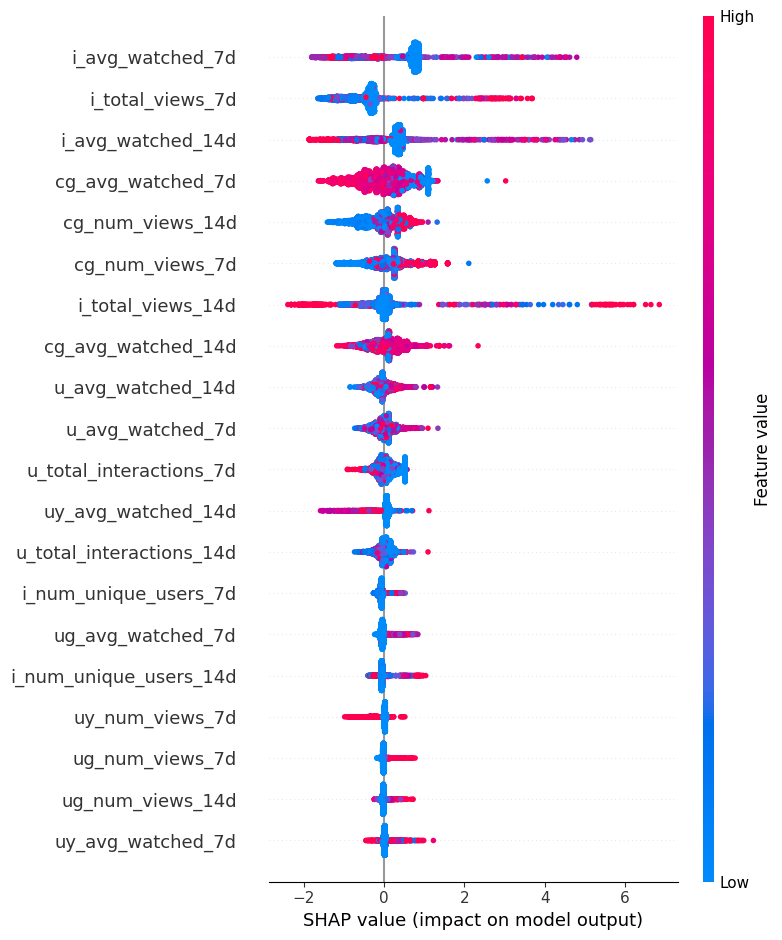

array([[-0.01309352, -0.0638774 , -0.01543973, ..., -0.06758481,
        -0.06787697,  0.34603697],
       [-0.01705701,  0.01514055, -0.04450001, ..., -0.38606441,
        -0.05830984, -1.13889436],
       [-0.11653429, -0.05888587, -0.02180032, ...,  0.06111872,
        -0.03312759,  0.21682519],
       ...,
       [-0.02152085, -0.0180369 , -0.05598574, ..., -2.04895476,
        -0.22601033,  0.69067592],
       [-0.09758738, -0.03528238, -0.02038543, ..., -0.11107769,
        -0.0411132 ,  0.23944284],
       [-0.09006948, -0.05926776, -0.01794794, ..., -0.05056364,
        -0.04998292,  0.17283263]], shape=(5000, 32))

In [22]:
import shap


def compute_shap(ranker, dataset, feature_cols, sample_size=5000):
    """
    SHAP values для части датасета (чтобы не взорвать память).
    """

    sample_df = dataset.sample(n=min(sample_size, dataset.height), seed=42)

    X_sample = sample_df.select(feature_cols).to_pandas()

    explainer = shap.TreeExplainer(ranker)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    shap.summary_plot(shap_values, X_sample)

    return shap_values

compute_shap(ranker, train_data.sample(10000), feat_cols)


In [23]:
import numpy as np
from sklearn.metrics import ndcg_score


import numpy as np
from sklearn.metrics import ndcg_score


def evaluate_on_validation(
    dataset,
    score_col: str,
    target_col: str,
    user_col: str = "user_id",
    k_list=[5, 10],
):
    """
    Считает NDCG@K по каждому пользователю и усредняет.

    Parameters
    ----------
    dataset : pl.DataFrame
    score_col : str
        Название колонки с предсказанным скором
    target_col : str
        Название колонки с релевантностью (label)
    user_col : str
        Колонка query-группы (обычно user_id)
    k_list : list[int]
        Список K для NDCG@K
    """

    # --- извлекаем numpy ---
    users = dataset[user_col].to_numpy()
    scores = dataset[score_col].to_numpy()
    y_true = dataset[target_col].to_numpy()

    results = {}

    unique_users = np.unique(users)

    for k in k_list:
        ndcgs = []

        for user in unique_users:
            mask = users == user
            n_items = mask.sum()

            # пропускаем тривиальные случаи
            if n_items < 2:
                continue

            user_true = y_true[mask].reshape(1, -1)
            user_score = scores[mask].reshape(1, -1)

            ndcg = ndcg_score(user_true, user_score, k=k)
            ndcgs.append(ndcg)

        results[f"NDCG@{k}"] = float(np.mean(ndcgs)) if ndcgs else 0.0

    print("Validation metrics:")
    for metric, value in results.items():
        print(f"{metric}: {value:.6f}")

    return results


test_data = test_data.with_columns(
    pl.Series(ranker.predict(test_data.select(feat_cols).to_numpy())).alias('ranker_score')
)

/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


In [24]:
evaluate_on_validation(test_data, 'ranker_score', 'label')

Validation metrics:
NDCG@5: 0.884656
NDCG@10: 0.891910


{'NDCG@5': 0.8846564919213707, 'NDCG@10': 0.8919098533126816}

In [25]:
evaluate_on_validation(test_data, 'i_total_views_7d', 'label')

Validation metrics:
NDCG@5: 0.012143
NDCG@10: 0.018621


{'NDCG@5': 0.01214278676652596, 'NDCG@10': 0.018621292974377677}